<a href="https://colab.research.google.com/github/Samara856/Stroke_risk_dataset_ML/blob/main/stroke_risk_dataset_MLfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer

# --- Base Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, BaggingClassifier,
                               StackingClassifier, VotingClassifier, ExtraTreesClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB

In [8]:
df = pd.read_csv("/content/stroke_risk_dataset.csv")

In [9]:
df.columns

Index(['Chest Pain', 'Shortness of Breath', 'Irregular Heartbeat',
       'Fatigue & Weakness', 'Dizziness', 'Swelling (Edema)',
       'Pain in Neck/Jaw/Shoulder/Back', 'Excessive Sweating',
       'Persistent Cough', 'Nausea/Vomiting', 'High Blood Pressure',
       'Chest Discomfort (Activity)', 'Cold Hands/Feet', 'Snoring/Sleep Apnea',
       'Anxiety/Feeling of Doom', 'Age', 'Stroke Risk (%)',
       'At Risk (Binary)'],
      dtype='object')

In [10]:
df['At Risk (Binary)'].value_counts()

,count
At Risk (Binary),
1,45444
0,24556



EXPLORATORY DATA ANALYSIS
                                  count       mean        std   min   25%  \
Chest Pain                      70000.0   0.501871   0.500000   0.0   0.0   
Shortness of Breath             70000.0   0.496471   0.499991   0.0   0.0   
Irregular Heartbeat             70000.0   0.498886   0.500002   0.0   0.0   
Fatigue & Weakness              70000.0   0.500100   0.500004   0.0   0.0   
Dizziness                       70000.0   0.503043   0.499994   0.0   0.0   
Swelling (Edema)                70000.0   0.500557   0.500003   0.0   0.0   
Pain in Neck/Jaw/Shoulder/Back  70000.0   0.499186   0.500003   0.0   0.0   
Excessive Sweating              70000.0   0.503671   0.499990   0.0   0.0   
Persistent Cough                70000.0   0.500800   0.500003   0.0   0.0   
Nausea/Vomiting                 70000.0   0.501943   0.500000   0.0   0.0   
High Blood Pressure             70000.0   0.500643   0.500003   0.0   0.0   
Chest Discomfort (Activity)     70000.0   0.49955

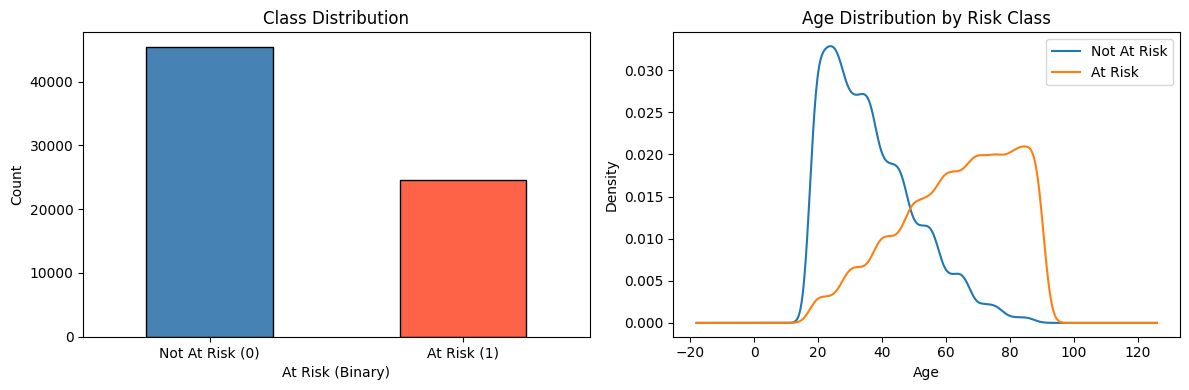

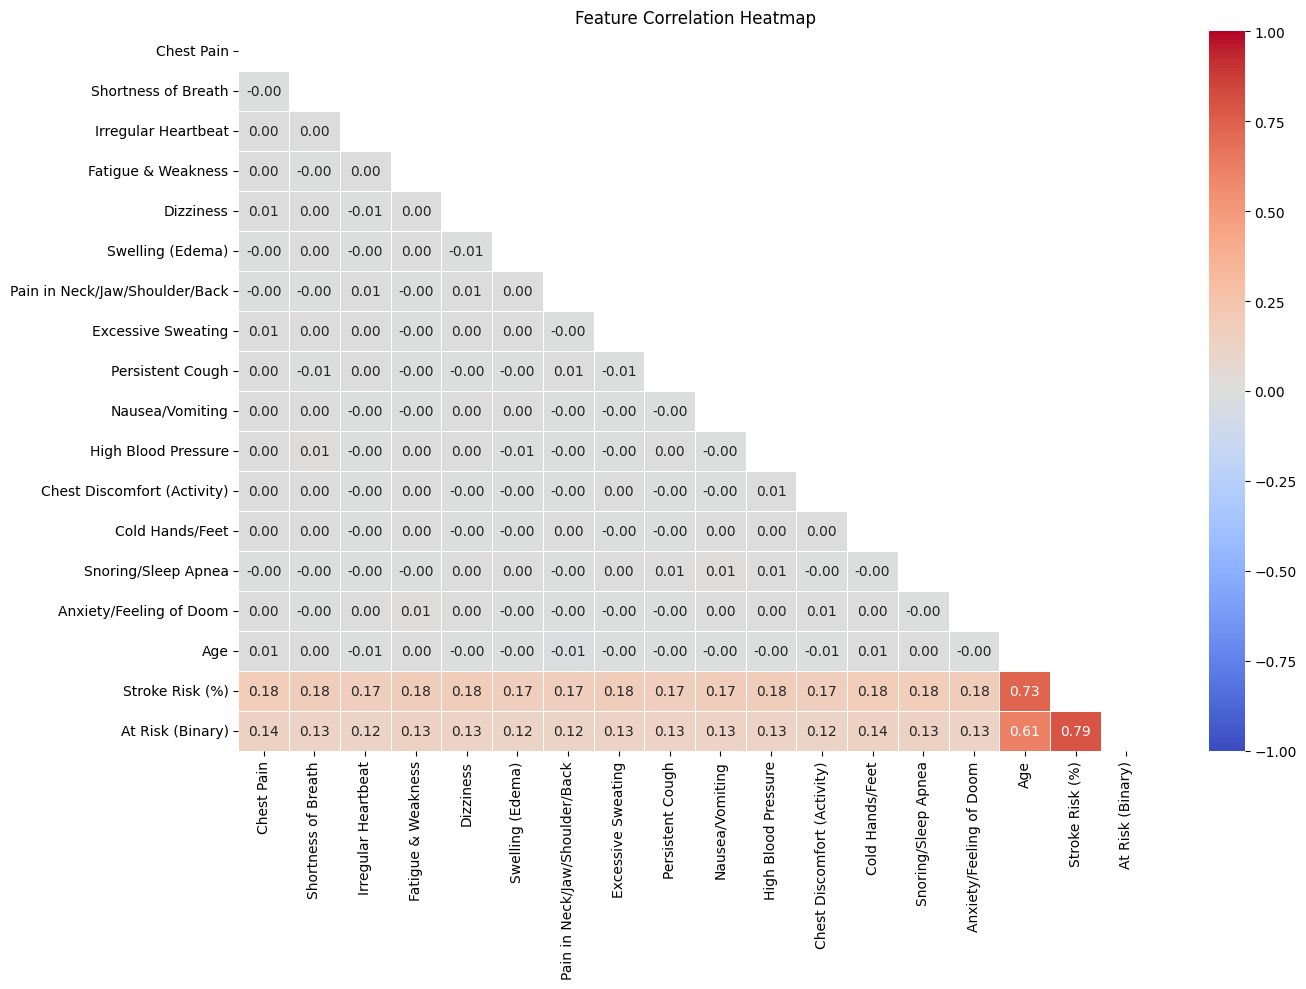

In [11]:
#3. EXPLORATORY DATA ANALYSIS
print("\n" + "=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)
print(df.describe().T)

# Class balance bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['At Risk (Binary)'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Not At Risk (0)', 'At Risk (1)'], rotation=0)
axes[0].set_ylabel('Count')

# Age distribution by class
df.groupby('At Risk (Binary)')['Age'].plot(kind='kde', ax=axes[1], legend=True)
axes[1].set_title('Age Distribution by Risk Class')
axes[1].set_xlabel('Age')
axes[1].legend(['Not At Risk', 'At Risk'])

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150)
plt.show()

# Correlation heatmap
plt.figure(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()


In [12]:
# 4. FEATURE ENGINEERING & SPLIT (CORRECTED)
TARGET = 'At Risk (Binary)'

# Option 1: Drop ALL features that might leak information
# Including any derived features or highly correlated ones
DROP = ['Stroke Risk (%)']  # Already dropped

# Let's check correlations to identify any other potential leaks
correlation_matrix = df.corr()
target_correlations = correlation_matrix[TARGET].sort_values(ascending=False)
print("\nCorrelations with target:")
print(target_correlations)

# Identify features with suspiciously high correlation (>0.95)
high_corr_features = target_correlations[abs(target_correlations) > 0.95].index.tolist()
if TARGET in high_corr_features:
    high_corr_features.remove(TARGET)
if high_corr_features:
    print(f"\n⚠️ WARNING: Features with suspiciously high correlation ({high_corr_features})")
    DROP.extend(high_corr_features)

X = df.drop(columns=[TARGET] + DROP)
y = df[TARGET]

print(f"\nFeatures used : {list(X.columns)}")
print(f"Target        : {TARGET}")

# Train / Test split (stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"\nTrain size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")

# Feature scaling (needed for LR, KNN, SVM)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)


Correlations with target:
At Risk (Binary)                  1.000000
Stroke Risk (%)                   0.790743
Age                               0.612038
Cold Hands/Feet                   0.136642
Chest Pain                        0.135365
Snoring/Sleep Apnea               0.133681
Fatigue & Weakness                0.133060
Excessive Sweating                0.132806
High Blood Pressure               0.132301
Anxiety/Feeling of Doom           0.131466
Shortness of Breath               0.130482
Dizziness                         0.130444
Persistent Cough                  0.128700
Nausea/Vomiting                   0.128645
Irregular Heartbeat               0.124150
Chest Discomfort (Activity)       0.123640
Swelling (Edema)                  0.122416
Pain in Neck/Jaw/Shoulder/Back    0.120280
Name: At Risk (Binary), dtype: float64

Features used : ['Chest Pain', 'Shortness of Breath', 'Irregular Heartbeat', 'Fatigue & Weakness', 'Dizziness', 'Swelling (Edema)', 'Pain in Neck/Jaw/Shoulder/

In [13]:
# ── 5. HELPER FUNCTION ───────────────────────────────────────
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, needs_scaling=False):
    """Train, predict, and return a metrics dict."""

    if needs_scaling:
        # assume X_tr, X_te already scaled outside OR pass scaler inside
        Xtr, Xte = X_tr, X_te
    else:
        Xtr, Xte = X_tr, X_te

    model.fit(Xtr, y_tr)
    y_pred = model.predict(Xte)

    y_prob = (
        model.predict_proba(Xte)[:, 1]
        if hasattr(model, 'predict_proba')
        else None
    )

    # (rest of your metrics calculation here)

    metrics = {
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(y_te, y_pred),      4),
        'Precision' : round(precision_score(y_te, y_pred),     4),
        'Recall'    : round(recall_score(y_te, y_pred),        4),
        'F1 Score'  : round(f1_score(y_te, y_pred),            4),
        'ROC-AUC'   : round(roc_auc_score(y_te, y_prob), 4) if y_prob is not None else 'N/A',
    }
    return metrics, model, y_pred

In [14]:
# ── 6. TRAIN MODELS WITH FIXED LOGISTIC REGRESSION ──
print("\n" + "=" * 60)
print("TRAINING MODELS (WITH FIXED LOGISTIC REGRESSION)")
print("=" * 60)

models_cfg = [
    ("Logistic Regression (L2, C=0.0001)", LogisticRegression(C=0.0001, max_iter=1000, random_state=42), True),
     ("Decision Tree", DecisionTreeClassifier(max_depth=5, random_state=42), False),  # Limit depth to prevent overfitting
    ("Random Forest", RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42), False),
    ("Extra Trees", ExtraTreesClassifier(n_estimators=100, max_depth=10, random_state=42), False),
    ("KNN", KNeighborsClassifier(n_neighbors=10), True),  # Increased neighbors
    ("SVM", SVC(probability=True, kernel='rbf', C=1.0, random_state=42), True),
    ("Naive Bayes", GaussianNB(), True),
    ("Gradient Boosting", GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42), False),
    ("XGBoost", XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        verbosity=0,
        max_depth=3,
        learning_rate=0.1
    ), False),
    ("LightGBM", LGBMClassifier(random_state=42, verbose=-1, max_depth=3, learning_rate=0.1), False),

]

results = []
trained_models = {}

for name, model, scaled in models_cfg:
    print(f"  → Training {name}...", end=' ')

    # Choose correct dataset
    if scaled:
        X_tr, X_te = X_train_sc, X_test_sc
    else:
        X_tr, X_te = X_train, X_test

    # Train + evaluate
    metrics, fitted, y_pred = evaluate_model(
        name, model,
        X_tr, y_train,
        X_te, y_test,
        needs_scaling=False
    )

    results.append(metrics)
    trained_models[name] = (fitted, scaled, y_pred)

    print(f"Acc={metrics['Accuracy']}  F1={metrics['F1 Score']}  AUC={metrics['ROC-AUC']}")

results_df = pd.DataFrame(results).set_index('Model')

print("\n📊 FIXED MODEL RESULTS:")
print(results_df.to_string())







TRAINING MODELS (WITH FIXED LOGISTIC REGRESSION)
  → Training Logistic Regression (L2, C=0.0001)... Acc=0.8983  F1=0.9274  AUC=0.9991
  → Training Decision Tree... Acc=0.8224  F1=0.8646  AUC=0.8956
  → Training Random Forest... Acc=0.923  F1=0.9413  AUC=0.9816
  → Training Extra Trees... Acc=0.9271  F1=0.9457  AUC=0.9852
  → Training KNN... Acc=0.9174  F1=0.9364  AUC=0.9736
  → Training SVM... Acc=0.9922  F1=0.994  AUC=0.9998
  → Training Naive Bayes... Acc=0.9296  F1=0.9464  AUC=0.9779
  → Training Gradient Boosting... Acc=0.9609  F1=0.9703  AUC=0.9919
  → Training XGBoost... Acc=0.9585  F1=0.9684  AUC=0.9938
  → Training LightGBM... Acc=0.958  F1=0.968  AUC=0.9937

📊 FIXED MODEL RESULTS:
                                    Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                                             
Logistic Regression (L2, C=0.0001)    0.8983     0.8645  1.0000    0.9274   0.9991
Decision Tree                         0.8224     0.

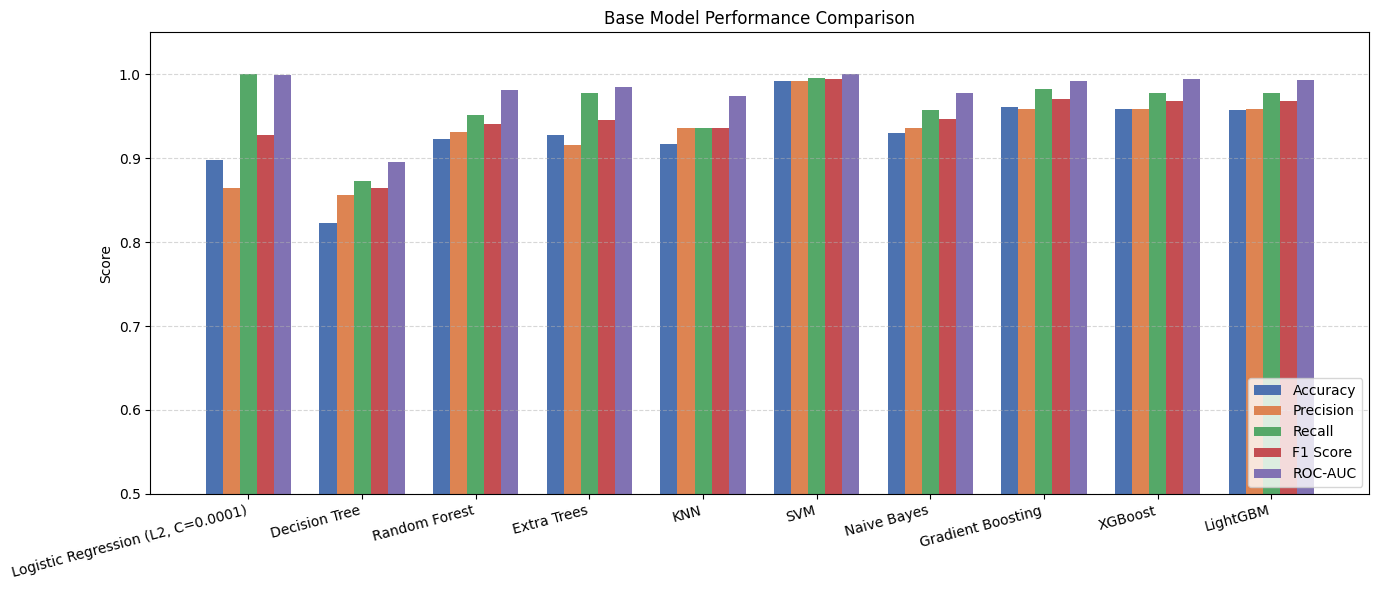

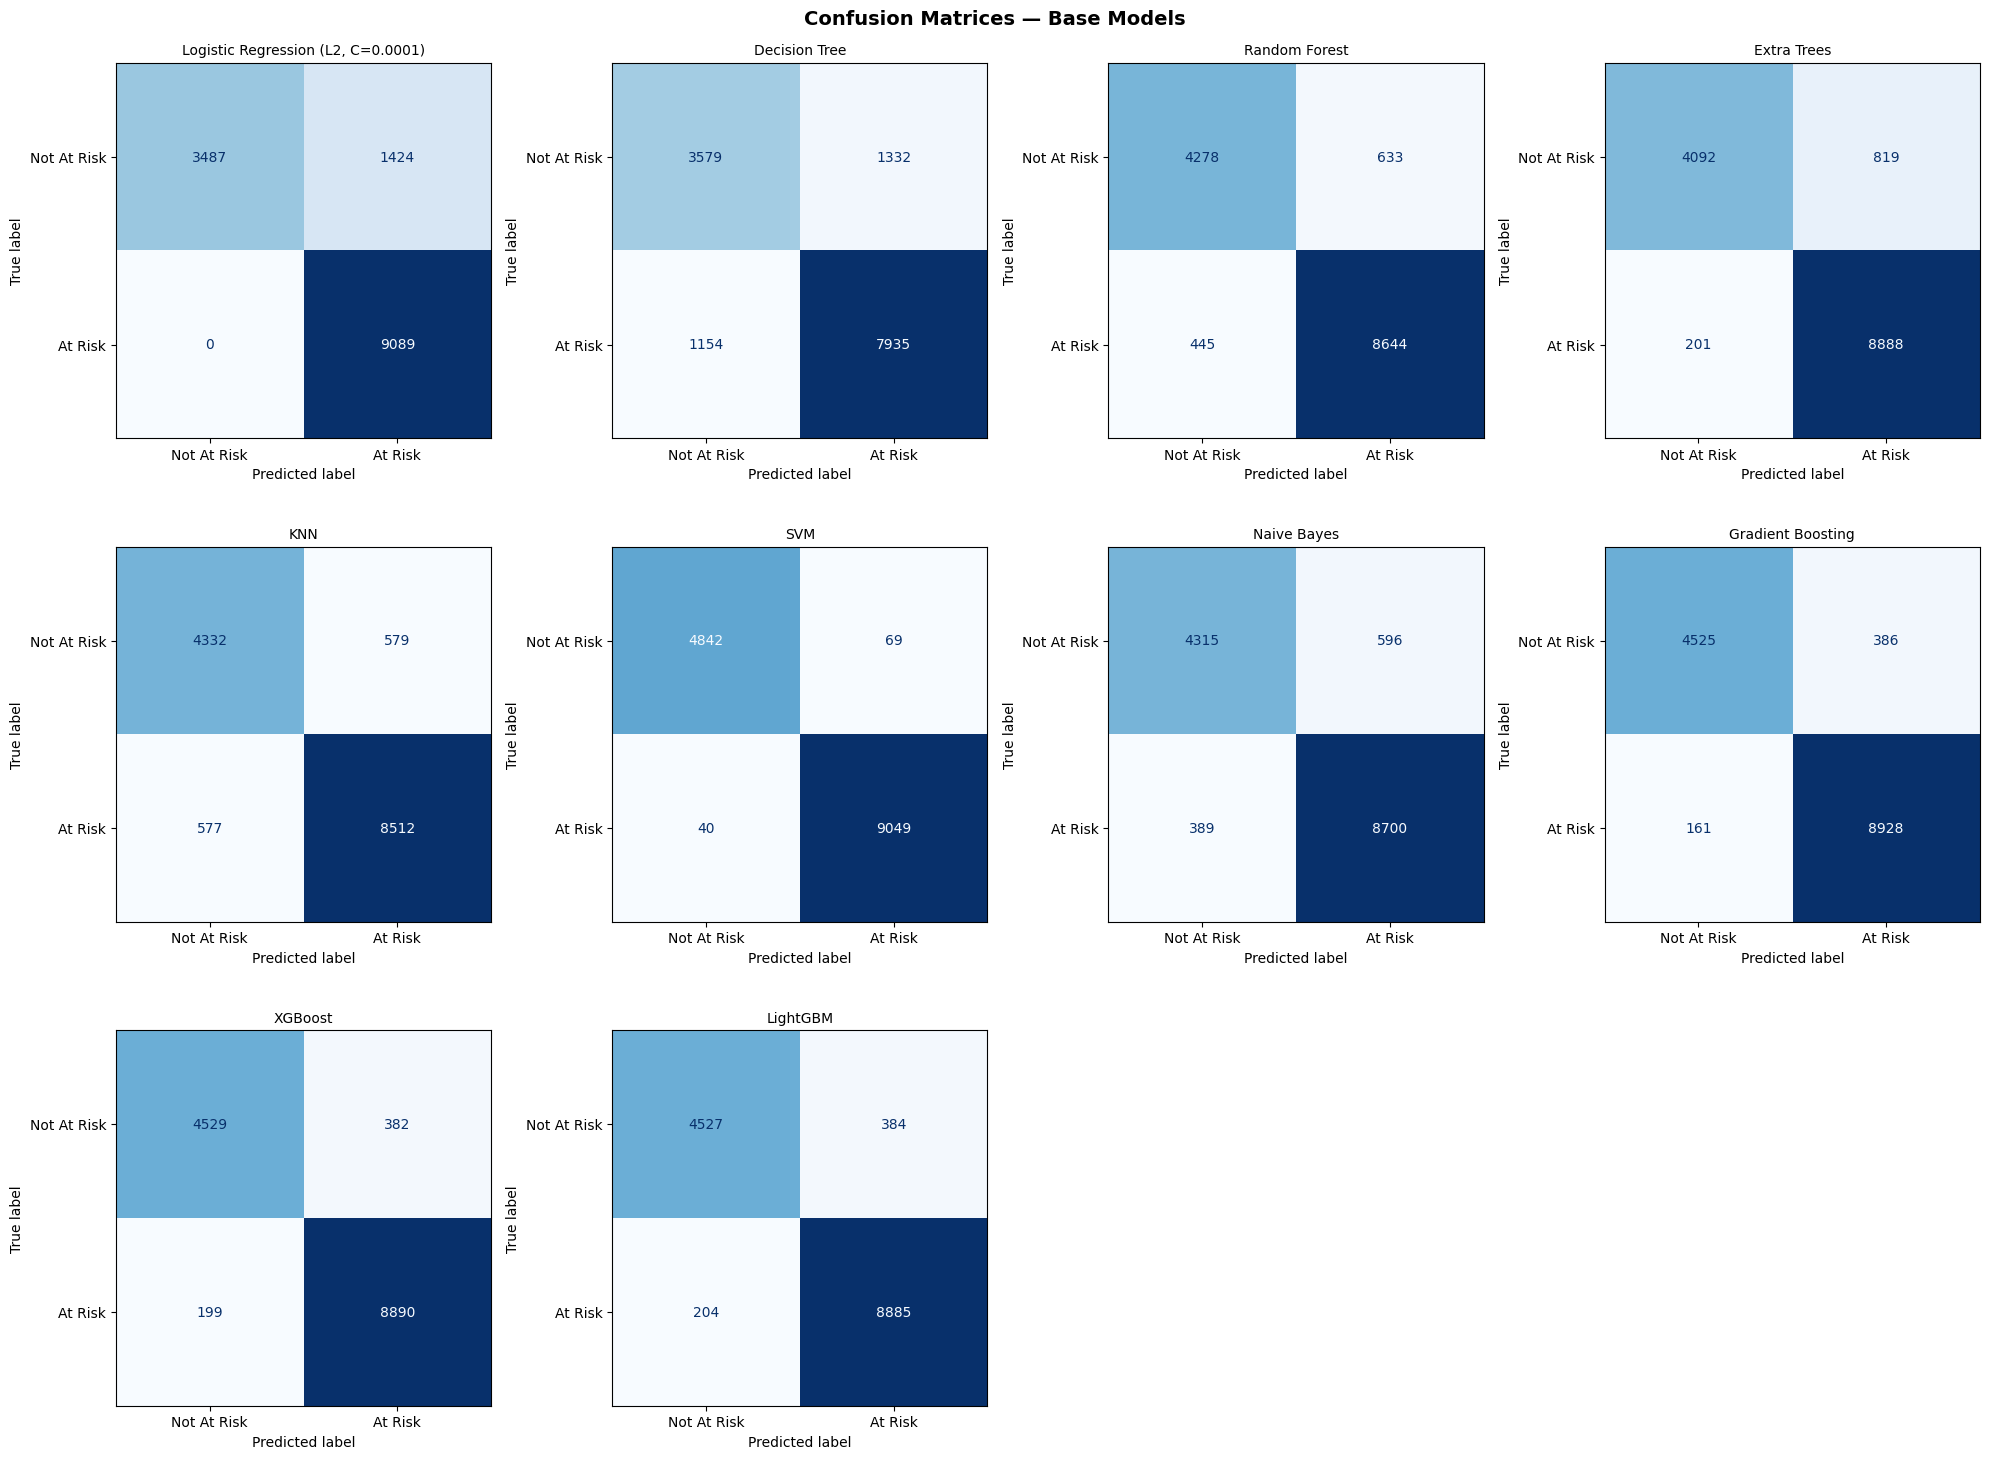

In [15]:
# ── 7. VISUALISE BASE MODEL METRICS ──────────────────────────
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
plot_df = results_df[metrics_to_plot].astype(float)

fig, ax = plt.subplots(figsize=(14, 6))
x   = np.arange(len(plot_df))
w   = 0.15
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B3']

for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * w, plot_df[metric], width=w, label=metric, color=colors[i])

ax.set_xticks(x + w * 2)
ax.set_xticklabels(plot_df.index, rotation=15, ha='right')
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score')
ax.set_title('Base Model Performance Comparison')
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('base_model_comparison.png', dpi=150)
plt.show()

# Confusion matrices for all models
num_models = len(trained_models)
rows = (num_models + 3) // 4  # Calculate rows needed for 4 columns
fig, axes = plt.subplots(rows, 4, figsize=(20, 5 * rows))
axes = axes.flatten()

for idx, (name, (fitted, scaled, y_pred)) in enumerate(trained_models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not At Risk', 'At Risk'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(name, fontsize=10)

# Turn off any unused subplots
for i in range(num_models, len(axes)): # Iterate from the number of models to the total number of axes
    axes[i].axis('off')

plt.suptitle('Confusion Matrices — Base Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_base.png', dpi=150)
plt.show()




